In [2]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torchvision.models import resnet50, ResNet50_Weights
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [3]:
sys.path.append("..")

from src.data import get_dataloaders

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print("Using device:", device)

Using device: mps


In [5]:
dataset_path = Path(
    "/Users/amirhossein/.cache/kagglehub/datasets/"
    "unclesamulus/blood-cells-image-dataset/"
    "versions/2/bloodcells_dataset"
)

train_loader, val_loader, test_loader, class_names = get_dataloaders(
    dataset_path=dataset_path,
    image_size=224,
    batch_size=16
)

class_names

['basophil',
 'eosinophil',
 'erythroblast',
 'ig',
 'lymphocyte',
 'monocyte',
 'neutrophil',
 'platelet']

In [6]:
num_classes = len(class_names)

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model.load_state_dict(
    torch.load(
        "../models/resnet50_finetuned.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [7]:
target_layers = [model.layer4[-1]]

In [8]:
# Helper function to unnormalize image
def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img_tensor = img_tensor.cpu() * std + mean
    img_tensor = img_tensor.clamp(0, 1)

    return img_tensor

In [9]:
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

print("True labels:", labels[:8])
print("Predicted labels:", preds[:8])

True labels: tensor([0, 3, 3, 3, 1, 7, 0, 2], device='mps:0')
Predicted labels: tensor([0, 3, 3, 3, 1, 7, 0, 2], device='mps:0')


In [10]:
# Generate Grad-CAM for 1 image
image_index = 0

input_tensor = images[image_index].unsqueeze(0)

target_class = preds[image_index].item()
targets = [ClassifierOutputTarget(target_class)]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0, :]

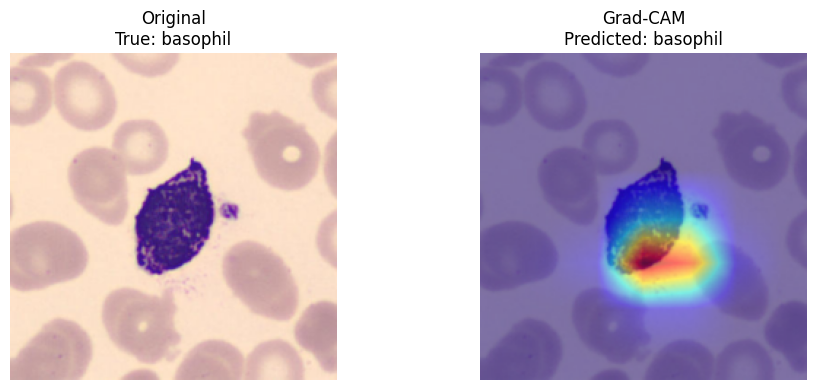

In [11]:
original_img = unnormalize(images[image_index])
original_img = original_img.permute(1, 2, 0).numpy()

cam_image = show_cam_on_image(
    original_img,
    grayscale_cam,
    use_rgb=True
)

true_class = class_names[labels[image_index].item()]
pred_class = class_names[preds[image_index].item()]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title(f"Original\nTrue: {true_class}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cam_image)
plt.title(f"Grad-CAM\nPredicted: {pred_class}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
print(original_img.shape)
print(original_img.min())
print(original_img.max())
print(original_img.dtype)

(224, 224, 3)
0.043137252
1.0
float32


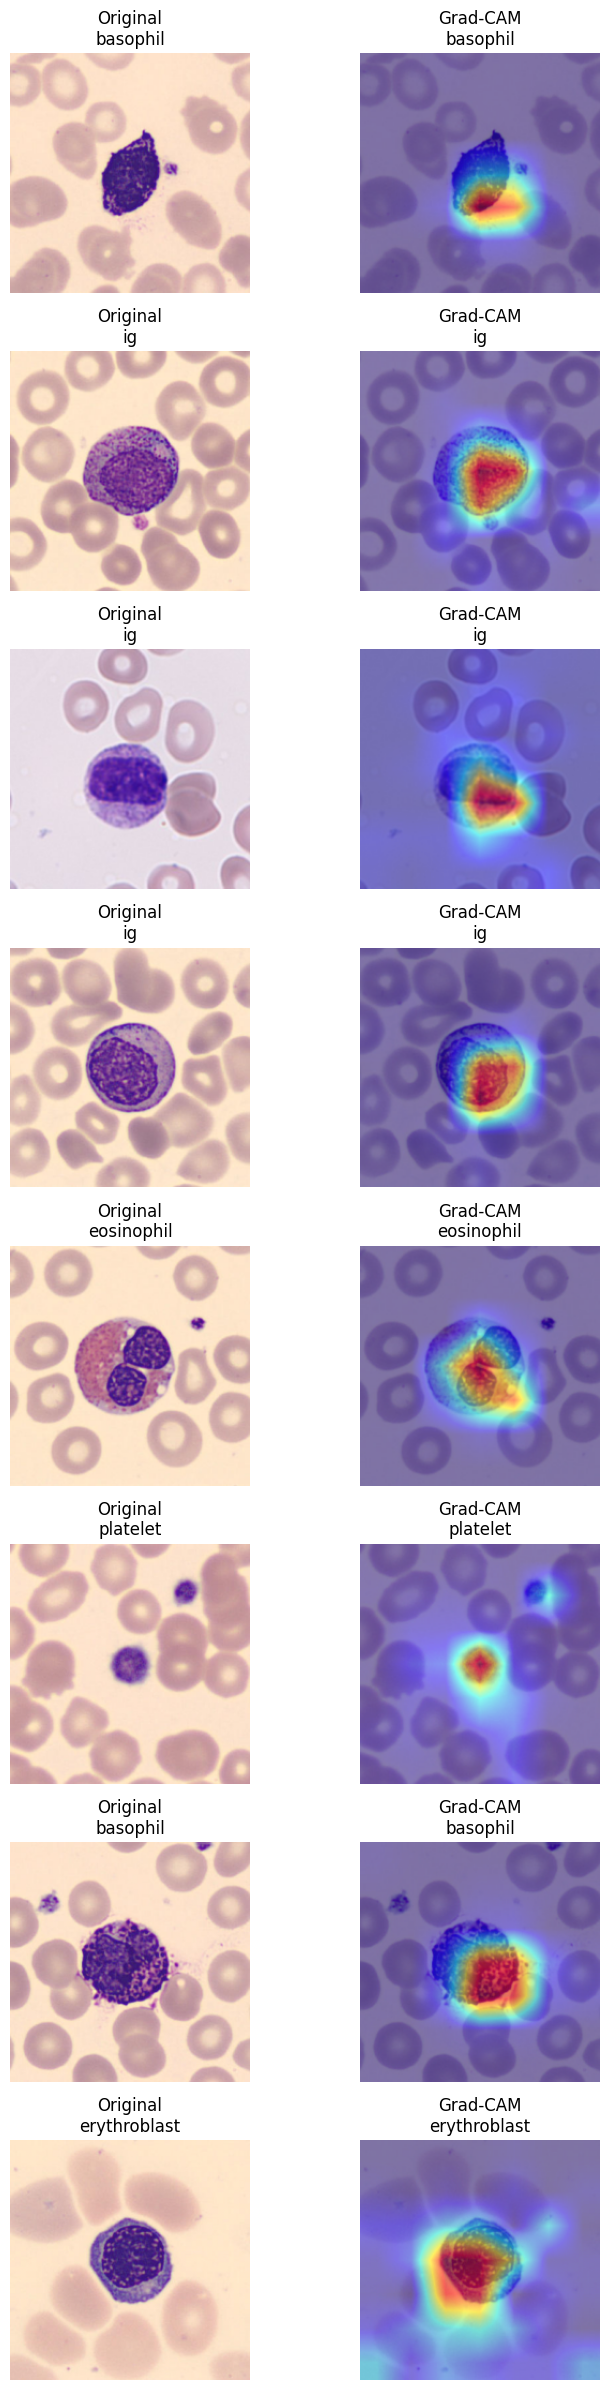

In [13]:
fig, axes = plt.subplots(
    8,
    2,
    figsize=(8, 24)
)

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

for i in range(8):

    input_tensor = images[i].unsqueeze(0)

    target_class = preds[i].item()

    targets = [
        ClassifierOutputTarget(target_class)
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    original_img = unnormalize(
        images[i]
    )

    original_img = (
        original_img
        .permute(1, 2, 0)
        .numpy()
    )

    cam_image = show_cam_on_image(
        original_img.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )

    true_class = class_names[
        labels[i].item()
    ]

    pred_class = class_names[
        preds[i].item()
    ]

    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title(
        f"Original\n{true_class}"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cam_image)
    axes[i, 1].set_title(
        f"Grad-CAM\n{pred_class}"
    )
    axes[i, 1].axis("off")

plt.tight_layout()

plt.savefig(
    "../figures/gradcam_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# Collect one correctly classified example from each class

examples = {}

model.eval()

for images, labels in test_loader:
    
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    for i in range(images.size(0)):
        
        true_label = labels[i].item()
        pred_label = preds[i].item()
        
        # Only keep correctly classified examples
        if true_label == pred_label and true_label not in examples:
            examples[true_label] = {
                "image": images[i].detach().cpu(),
                "label": true_label,
                "prediction": pred_label
            }

    if len(examples) == len(class_names):
        break

print("Collected classes:")
for label_idx in sorted(examples.keys()):
    print(label_idx, class_names[label_idx])

Collected classes:
0 basophil
1 eosinophil
2 erythroblast
3 ig
4 lymphocyte
5 monocyte
6 neutrophil
7 platelet


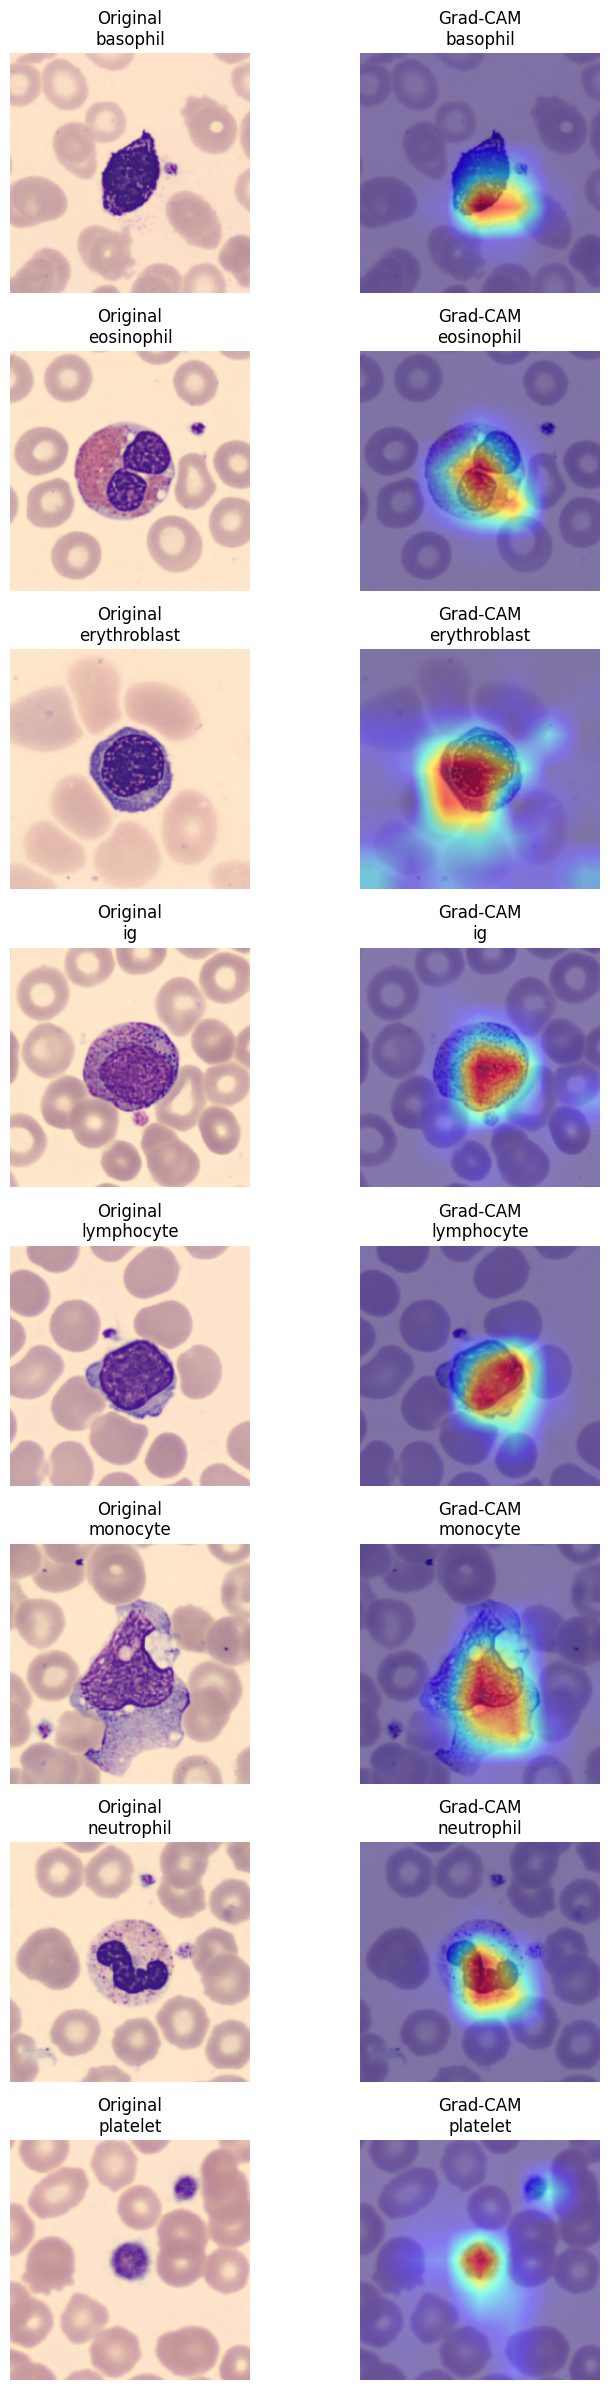

In [16]:
fig, axes = plt.subplots(
    len(class_names),
    2,
    figsize=(8, 24)
)

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

for row, class_idx in enumerate(sorted(examples.keys())):
    
    example = examples[class_idx]
    
    image_tensor = example["image"].to(device)
    input_tensor = image_tensor.unsqueeze(0)
    
    target_class = example["prediction"]
    targets = [ClassifierOutputTarget(target_class)]
    
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]
    
    original_img = unnormalize(image_tensor)
    original_img = original_img.permute(1, 2, 0).numpy()
    
    cam_image = show_cam_on_image(
        original_img.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )
    
    class_name = class_names[class_idx]
    
    axes[row, 0].imshow(original_img)
    axes[row, 0].set_title(f"Original\n{class_name}")
    axes[row, 0].axis("off")
    
    axes[row, 1].imshow(cam_image)
    axes[row, 1].set_title(f"Grad-CAM\n{class_name}")
    axes[row, 1].axis("off")

plt.tight_layout()

plt.savefig(
    "../figures/gradcam_one_per_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Grad-CAM Explainability Analysis

## Objective

Grad-CAM was applied to the fine-tuned ResNet50 model to visualize which image regions contributed most strongly to each prediction.

The goal is to determine whether the model bases its decisions on biologically meaningful cellular structures rather than background artifacts.

## Qualitative Results

Grad-CAM visualizations were generated for one correctly classified example from each blood cell category.

Across all classes, the highest activation regions are concentrated on the target white blood cell rather than the surrounding red blood cells or image background.

Several consistent patterns emerge:

- Basophil attention is concentrated within the dense granular region of the cell.
- Eosinophil attention focuses on the segmented nucleus and surrounding granular structures.
- Erythroblast attention is centered on the large dark nucleus occupying most of the cell.
- Immature granulocyte (IG) attention highlights the internal cellular texture and nuclear region.
- Lymphocyte attention focuses primarily on the central nucleus.
- Monocyte attention is distributed across the larger irregular cell body and nuclear structure.
- Neutrophil attention concentrates on the segmented nucleus, which is a defining morphological characteristic.
- Platelet attention is focused almost exclusively on the platelet itself despite the presence of many surrounding red blood cells.

## Biological Interpretation

The highlighted regions correspond closely to features used by human experts when identifying blood cell types, including:

- Nuclear shape
- Nuclear segmentation
- Granulation patterns
- Cell morphology
- Relative cell size

This suggests that the model has learned meaningful morphological representations rather than relying on irrelevant image characteristics.

## Reliability and Trustworthiness

An important observation is that the model generally ignores large portions of the background and nearby red blood cells.

If the heatmaps consistently highlighted empty image regions or unrelated cells, it would suggest that the model had learned spurious correlations. Instead, the Grad-CAM visualizations indicate that predictions are driven primarily by the target white blood cell.

This increases confidence that the model's high classification accuracy reflects genuine feature learning rather than dataset artifacts.

## Limitations

Grad-CAM provides a qualitative explanation of model behavior but does not establish causal reasoning. The heatmaps identify influential regions but do not prove that the model reasons in the same way as a human hematologist.

Future work could compare Grad-CAM results with expert annotations or incorporate additional explainability techniques such as Integrated Gradients, SHAP, or Occlusion Sensitivity.

## Conclusion

The Grad-CAM analysis demonstrates that the fine-tuned ResNet50 model primarily bases its predictions on biologically relevant cellular structures. Combined with the model's 98% test accuracy, these results suggest that the proposed classification pipeline is both highly accurate and reasonably interpretable for blood cell image classification.